<a href="https://colab.research.google.com/github/anadelrio18/emociones-voz/blob/main/Base_de_datos_en_aleman_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import librosa
import librosa.display
from pathlib import Path
from skimage.filters import threshold_otsu


In [ ]:

# Download latest version
ruta_base = kagglehub.dataset_download("piyushagni5/berlin-database-of-emotional-speech-emodb")
CARPETA_aleman = Path(ruta_base)/"wav"
# Verificar
wavs = list(CARPETA_aleman.glob("**/*.wav"))
print(f"Audios encontrados: {len(wavs)}")
print(f"Ejemplo: {wavs[0].name}")

100%|██████████| 38.0M/38.0M [00:00<00:00, 72.0MB/s]

Extracting files...


Audios encontrados: 535
Ejemplo: 08a05Nb.wav


In [ ]:
#Para procesar todos los audios y hacer la comparación crearemos una función

def superprocesador(carpeta, emocion):
  archivos = list(carpeta.glob("*.wav"))
  print(f"Encontrados: {len(archivos)} audios")
  Imágenes = []
  for i in archivos:
    #Lee audio por audio
    audio, sr = librosa.load(i, sr=None)
    #forzar todos a 2.5 segundos
    n_muestras = int(sr * 2.5)
    if len(audio) >= n_muestras:
      audio = audio[:n_muestras]
    else:
      audio = np.pad(audio, (0, n_muestras - len(audio)))
    #Trans corta
    stft = librosa.stft(audio)
    spectrogram = np.abs(stft)
    #Binarizamos con Otsu
    spectrogram_db = librosa.amplitude_to_db(spectrogram, ref=np.max)
    threshold = threshold_otsu(spectrogram_db)
    binary_image = spectrogram_db > threshold
    #Aplicamos fourier 2d
    matriz_fourier_2d = np.fft.fft2(binary_image)
    matriz_fourier_2d_organizada = np.fft.fftshift(matriz_fourier_2d)
    modulo_final = np.abs(matriz_fourier_2d_organizada)
    #centro_y, centro_x = modulo_final.shape[0] // 2, modulo_final.shape[1] // 2
    #modulo_final[centro_y, centro_x] = 0
    #Guardamos la informacion general
    Imágenes.append(np.log1p(modulo_final))
  #Sacamos el promedio gg
  promedio = np.mean(Imágenes, axis=0)
  #Graficamos
  plt.figure(figsize=(10,6))
  plt.imshow(promedio, aspect='auto', origin='lower', cmap='gray')
  plt.title(f"Espectro 2D promedio — {len(Imágenes)} audios")
  plt.show()
  # perfil de línea vertical
  perfil = promedio[:, promedio.shape[1] // 2]
  plt.figure(figsize=(10, 4))
  plt.plot(perfil)
  plt.title(f"Perfil de línea vertical — emoción {emocion} ")
  plt.ylim(np.min(perfil) - 0.2, np.max(perfil) + 0.2)
  plt.xlabel("Píxel")
  plt.ylabel("Intensidad")
  plt.show()
  return

In [ ]:
#Diccionario de emociones según la nomenclatura de EMO-DB
EMOCIONES_EMODB = {
    'W': 'Anger (Ira)',
    'L': 'Boredom (Aburrimiento)',
    'A': 'Anxiety (Ansiedad)',
    'F': 'Happiness (Felicidad)',
    'T': 'Sadness (Tristeza)',
    'E': 'Disgust (Disgusto)',
    'N': 'Neutral'
}

def analizar_emocion(carpeta, codigo_emocion, duracion_seg=2.5, n_fft=512, mostrar_graficas=True):
    """
    Analiza una emoción de la base de datos EMO-DB usando Doble Fourier.

    Parámetros:
    -----------
    carpeta        : str o Path — ruta a la carpeta con TODOS los audios mezclados
    codigo_emocion : str — letra de la emoción según EMO-DB:
                     'W'=Ira, 'L'=Aburrimiento, 'A'=Ansiedad,
                     'F'=Felicidad, 'T'=Tristeza, 'E'=Disgusto, 'N'=Neutral
    duracion_seg   : float — duración fija en segundos para todos los audios (default 2.5)
    n_fft          : int — tamaño de ventana STFT (default 512)
    mostrar_graficas: bool — si True, muestra espectro 2D promedio y perfil de línea

    Retorna:
    --------
    promedio : np.ndarray — imagen promedio del espectro 2D (en escala log)
    perfil   : np.ndarray — perfil de línea vertical central
    archivos_usados : list — lista de archivos que se procesaron
    """
    carpeta = Path(carpeta)
    codigo_emocion = codigo_emocion.upper()

    if codigo_emocion not in EMOCIONES_EMODB:
        raise ValueError(f"Código '{codigo_emocion}' no válido. Usa uno de: {list(EMOCIONES_EMODB.keys())}")

    nombre_emocion = EMOCIONES_EMODB[codigo_emocion]

    #Filtrar archivos: la posición 6 (índice 5) del nombre es el código de emoción
    todos_los_wavs = list(carpeta.glob("*.wav"))
    archivos_emocion = [f for f in todos_los_wavs if len(f.stem) >= 6 and f.stem[5].upper() == codigo_emocion]

    if len(archivos_emocion) == 0:
        raise FileNotFoundError(f"No se encontraron audios para la emoción '{nombre_emocion}' (código '{codigo_emocion}') en:\n{carpeta}")

    print(f"Emoción: {nombre_emocion}")
    print(f"Audios encontrados: {len(archivos_emocion)}")

    #Procesar cada audio
    espectros_2d = []
    hop_length = n_fft // 2
    n_muestras_fijo = None  # se define con el primer audio

    for ruta in archivos_emocion:
        try:
            audio, sr = librosa.load(ruta, sr=None)

            # Fijar duración
            n_muestras = int(sr * duracion_seg)
            if len(audio) >= n_muestras:
                audio = audio[:n_muestras]
            else:
                audio = np.pad(audio, (0, n_muestras - len(audio)))

            # STFT → espectrograma
            stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, window=('gaussian', n_fft//8))
            spectrogram_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

            # Binarización Otsu
            threshold = threshold_otsu(spectrogram_db)
            binary_image = (spectrogram_db > threshold).astype(np.float64)

            # FFT 2D
            fft2 = np.fft.fftshift(np.fft.fft2(binary_image))
            magnitud_log = np.log1p(np.abs(fft2))

            espectros_2d.append(magnitud_log)

        except Exception as e:
            print(f"  ⚠ Error procesando {ruta.name}: {e}")

    if len(espectros_2d) == 0:
        raise RuntimeError("No se pudo procesar ningún audio.")

    print(f"Procesados exitosamente: {len(espectros_2d)} audios")

    # Imagen promedio
    promedio = np.mean(espectros_2d, axis=0)

    # Perfil de línea vertical central
    perfil = promedio[:, promedio.shape[1] // 2]

    # Graficas
    if mostrar_graficas:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f"Análisis Doble Fourier — {nombre_emocion} ({len(espectros_2d)} audios)", fontsize=13)

        axes[0].imshow(promedio, aspect='auto', origin='lower', cmap='gray')
        axes[0].set_title("Espectro 2D promedio")
        axes[0].set_xlabel("Frecuencia espacial X")
        axes[0].set_ylabel("Frecuencia espacial Y")

        axes[1].plot(perfil, color='steelblue')
        axes[1].set_title("Perfil de línea vertical")
        axes[1].set_xlabel("Píxel")
        axes[1].set_ylabel("Intensidad (log)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return promedio, perfil, archivos_emocion

In [ ]:
from pathlib import Path

carpeta = Path(ruta_base)

archivos = list(carpeta.glob("**/*.wav"))
print(f"Total de archivos: {len(archivos)}")
print("\nPrimeros 10 nombres:")
for f in archivos[:10]:
    print(f"  nombre: '{f.stem}'  → índice 5: '{f.stem[5] if len(f.stem) > 5 else 'DEMASIADO CORTO'}'")

Total de archivos: 535

Primeros 10 nombres:
  nombre: '08a05Nb'  → índice 5: 'N'
  nombre: '13b03Td'  → índice 5: 'T'
  nombre: '13a01Ea'  → índice 5: 'E'
  nombre: '03a05Wb'  → índice 5: 'W'
  nombre: '11a05Fc'  → índice 5: 'F'
  nombre: '16a04Nc'  → índice 5: 'N'
  nombre: '08b09Fd'  → índice 5: 'F'
  nombre: '15b10Nb'  → índice 5: 'N'
  nombre: '12b03La'  → índice 5: 'L'
  nombre: '08b02La'  → índice 5: 'L'


Emoción: Anger (Ira)
Audios encontrados: 127
Procesados exitosamente: 127 audios


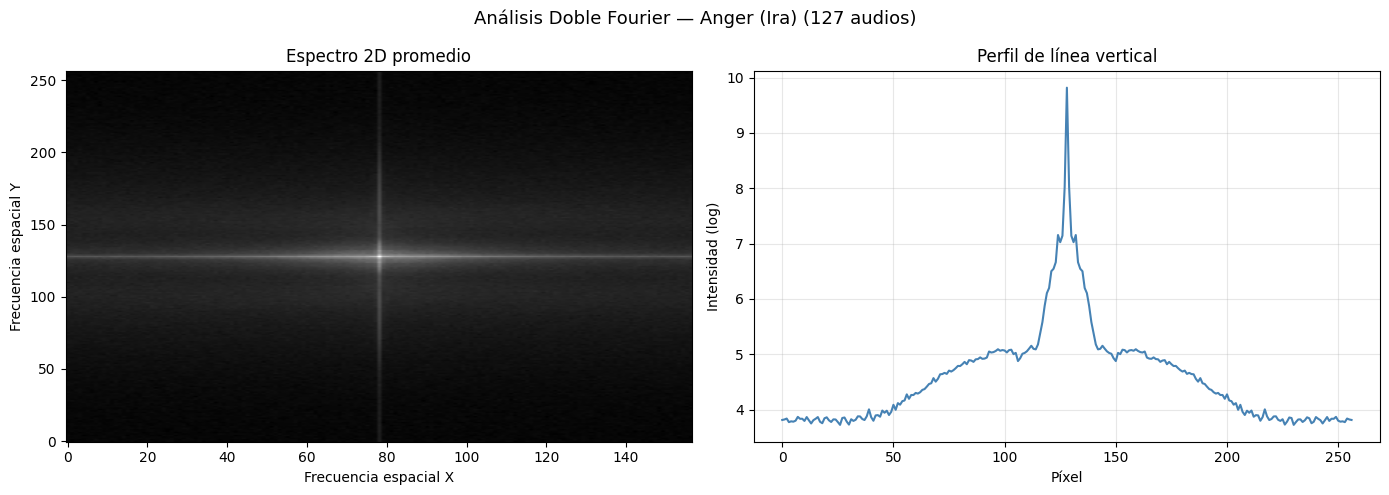

In [ ]:
promedio_anger, perfil_anger, archivos_anger = analizar_emocion(CARPETA_aleman, 'W')